El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales simple, con un total de 6 capas.

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2025-11-17 08:53:26.588440: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 08:53:26.682915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-17 08:53:26.730248: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-17 08:53:26.743624: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-17 08:53:26.811006: I tensorflow/core/platform/cpu_feature_guar

Funciones

In [4]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [2]:
def mostrar_resultados2(
    X, y, y_pred, n=5, cmap='viridis',
    titulo_general="Comparación de Resultados",
    xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):

    n = min(n, len(X))

    # Tamaño de la figura (ajustado para evitar solapamientos)
    fig, axs = plt.subplots(n, 3, figsize=(14, 4.2 * n))

    # Espacio ajustado para evitar traslapes
    fig.subplots_adjust(
        top=0.93,       # espacio superior
        bottom=0.05,
        left=0.05,
        right=0.80,
        hspace=0.35,    # espacio vertical entre filas
        wspace=0     # espacio horizontal entre columnas
    )

    fig.suptitle(titulo_general, fontsize=18)

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}', fontsize=11)
        axs[i, 0].set_xlabel(xlabel, fontsize=10)
        axs[i, 0].set_ylabel(ylabel, fontsize=10)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}', fontsize=11)
        axs[i, 1].set_xlabel(xlabel, fontsize=10)
        axs[i, 1].set_ylabel(ylabel, fontsize=10)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}', fontsize=11)
        axs[i, 2].set_xlabel(xlabel, fontsize=10)
        axs[i, 2].set_ylabel(ylabel, fontsize=10)

    plt.show()

In [9]:
def mostrar_resultados3(
    X, y, y_pred, n=1, cmap='viridis',
    titulo_general="Comparación de Resultados",
    xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):

    n = min(n, len(X))

    # Tamaño de la figura para 1 fila y 3 columnas
    fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))

    # Espacio ajustado para evitar traslapes
    fig.subplots_adjust(
        top=0.85,       # espacio superior reducido
        bottom=0.05,
        left=0.05,
        right=0.95,     # espacio derecho aumentado
        hspace=0.35,    # espacio vertical entre filas
        wspace=0.2      # espacio horizontal entre columnas
    )

    fig.suptitle(titulo_general, fontsize=18)

    # Solo mostramos la primera muestra (i=0)
    i = 0
    
    # Entrada
    axs[0].imshow(X[i, ..., 0], cmap=cmap)
    axs[0].set_title(f'Entrada t={i}', fontsize=11)
    axs[0].set_xlabel(xlabel, fontsize=10)
    axs[0].set_ylabel(ylabel, fontsize=10)

    # Real
    axs[1].imshow(y[i, ..., 0], cmap=cmap)
    axs[1].set_title(f'Real t+1={i+1}', fontsize=11)
    axs[1].set_xlabel(xlabel, fontsize=10)
    axs[1].set_ylabel(ylabel, fontsize=10)

    # Predicción
    axs[2].imshow(y_pred[i, ..., 0], cmap=cmap)
    axs[2].set_title(f'Predicción t+1={i+1}', fontsize=11)
    axs[2].set_xlabel(xlabel, fontsize=10)
    axs[2].set_ylabel(ylabel, fontsize=10)

    plt.show()

In [3]:
    # Directorio con imagenes en tamaño original y  tamaño reducido
    # d_original = '/home/jhon/banda13/ene_may_5m'
    d_reducida = '/home/jhon/banda13/ene_may_5m_reducida'

    #Llamado de función para redimensionar imágenes
    #resize_npy_images(d_original, d_reducida, new_size=(480, 480))

    # Cargar las imágenes
    file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
    print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

    images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

    # Normalización
    all_pixels = np.concatenate([img.flatten() for img in images])
    global_min, global_max = np.min(all_pixels), np.max(all_pixels)

    images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
    images = [np.clip(img, 0, 1) for img in images]

    X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
    y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

    print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
    print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida


Procesando 3618 imágenes
Forma de X: (3617, 480, 480, 1)
Forma de y: (3617, 480, 480, 1)


Creación del modelo

In [4]:
semilla = 42
tf.random.set_seed(semilla)

model1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (1, 1), activation='linear', padding='same')  # SIN BatchNorm en la salida
])

model1.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model1.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo1_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# Entrenamiento
print("Iniciando entrenamiento")
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history1.history['loss'][-1]:.4f}")

/home/jhon/cloud/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-17 08:54:44.385517: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46780 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

...

724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.1753 - root_mean_squared_error: 0.0723 - val_loss: 0.0070 - val_mean_absolute_percentage_error: 20.3823 - val_root_mean_squared_error: 0.0837
Epoch 6/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0052 - mean_absolute_percentage_error: 14.9654 - root_mean_squared_error: 0.0720
Epoch 6: val_loss improved from 0.00700 to 0.00693, saving model to modelo1_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.1384 - root_mean_squared_error: 0.0721 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.3430 - val_root_mean_squared_error: 0.0833
Epoch 7/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0052 - mean_absolute_percentage_error: 14.9216 - root_mean_squared_error: 0.0718
Epoch 7: val_loss improved from 0.00693 to 0.00692, saving model to modelo1_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.1143 - root_mean_squared_error: 0.0720 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.5234 - val_root_mean_squared_error: 0.0832
Epoch 8/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.8865 - root_mean_squared_error: 0.0717
Epoch 8: val_loss did not improve from 0.00692
724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.1150 - root_mean_squared_error: 0.0719 - val_loss: 0.0070 - val_mean_absolute_percentage_error: 21.1311 - val_root_mean_squared_error: 0.0836
Epoch 9/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.8336 - root_mean_squared_error: 0.0715
Epoch 9: val_loss improved from 0.00692 to 0.00690, saving model to modelo1_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.0975 - root_mean_squared_error: 0.0719 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.9221 - val_root_mean_squared_error: 0.0831
Epoch 10/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.8008 - root_mean_squared_error: 0.0714
Epoch 10: val_loss improved from 0.00690 to 0.00688, saving model to modelo1_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.0637 - root_mean_squared_error: 0.0718 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.6225 - val_root_mean_squared_error: 0.0829
Epoch 11/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7775 - root_mean_squared_error: 0.0713
Epoch 11: val_loss did not improve from 0.00688
724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0051 - mean_absolute_percentage_error: 15.0377 - root_mean_squared_error: 0.0717 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.6825 - val_root_mean_squared_error: 0.0830
Epoch 12/50
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7662 - root_mean_squared_error: 0.0713
Epoch 12: val_loss did not improve from 0.00688
724/724 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 0.0051 - mean_absolute_percentage_error: 15.0141 - root_mean_squared_error: 0.0717 - val_

Valores de las metricas

In [5]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model1.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.4183 - root_mean_squared_error: 0.0711
Pérdida (MSE): 0.0051
RMSE: 0.0711
MAPE: 14.4183


In [6]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model1.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 281ms/step - loss: 0.0069 - mean_absolute_percentage_error: 20.6225 - root_mean_squared_error: 0.0829
Pérdida (MSE): 0.0069
RMSE: 0.0829
MAPE: 20.6225


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0051, RMSE final: 0.0713, MAPE final: 14.8615
Validación    - Loss final: 0.0070, RMSE final: 0.0835, MAPE final: 21.0178


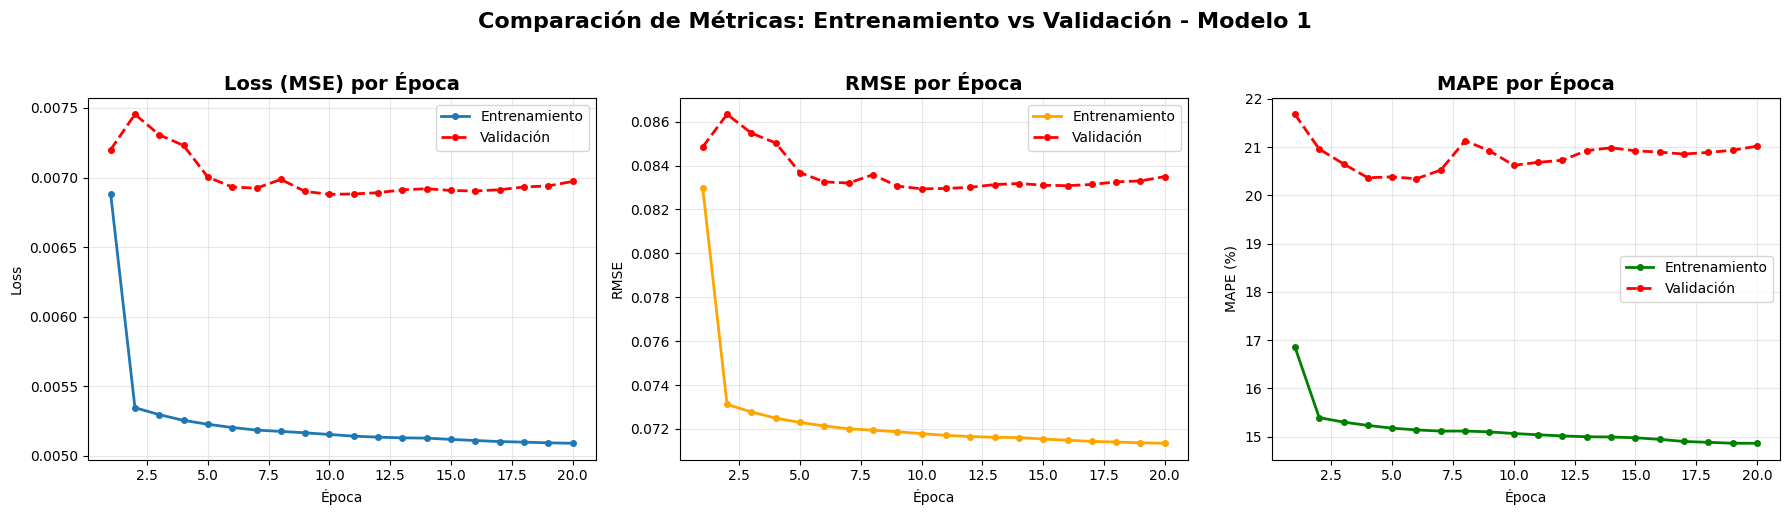

In [13]:
# Extraer métricas del historial (entrenamiento y validación)
loss = history1.history['loss']
val_loss = history1.history['val_loss']

rmse = history1.history['root_mean_squared_error']
val_rmse = history1.history['val_root_mean_squared_error']

mape = history1.history['mean_absolute_percentage_error']
val_mape = history1.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 1',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Visualización de imagenes

91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step


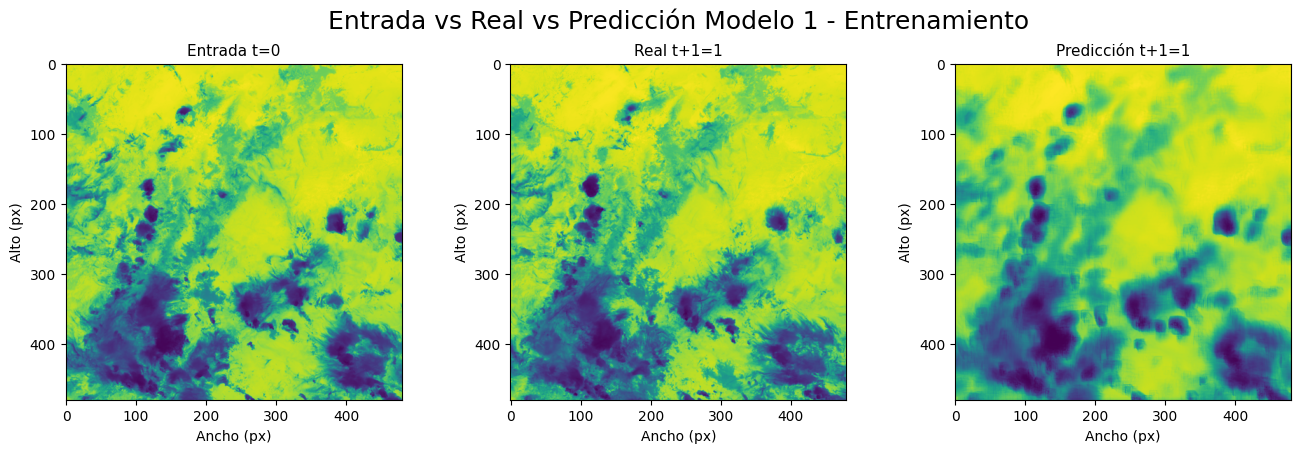

In [12]:
y_pred1 = model1.predict(X_train)  # Genera las predicciones
mostrar_resultados3(
    X_train, y_train, y_pred1, n=1,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Prueba

In [6]:
# Directorio original y reducido
d_jun_1m = '/home/fisica/bandas/banda13/jun_1m'
d_jun_1m_red = '/home/fisica/bandas/banda13/jun_1m_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_jun_1m, d_jun_1m_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_jun_1m_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_test = [np.load(os.path.join(d_jun_1m_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida

Procesando 716 imágenes
Forma de X: (715, 480, 480, 1)
Forma de y: (715, 480, 480, 1)


2025-10-30 20:59:24.857382: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 658944000 exceeds 10% of free system memory.
2025-10-30 20:59:25.753225: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 29491200 bytes after encountering the first element of size 29491200 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-10-30 20:59:25.918271: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 471859200 exceeds 10% of free system memory.
2025-10-30 20:59:26.135834: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 943718400 exceeds 10% of free system memory.
2025-10-30 20:59:26.751516: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1887436800 exceeds 10% of free system memory.


23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step


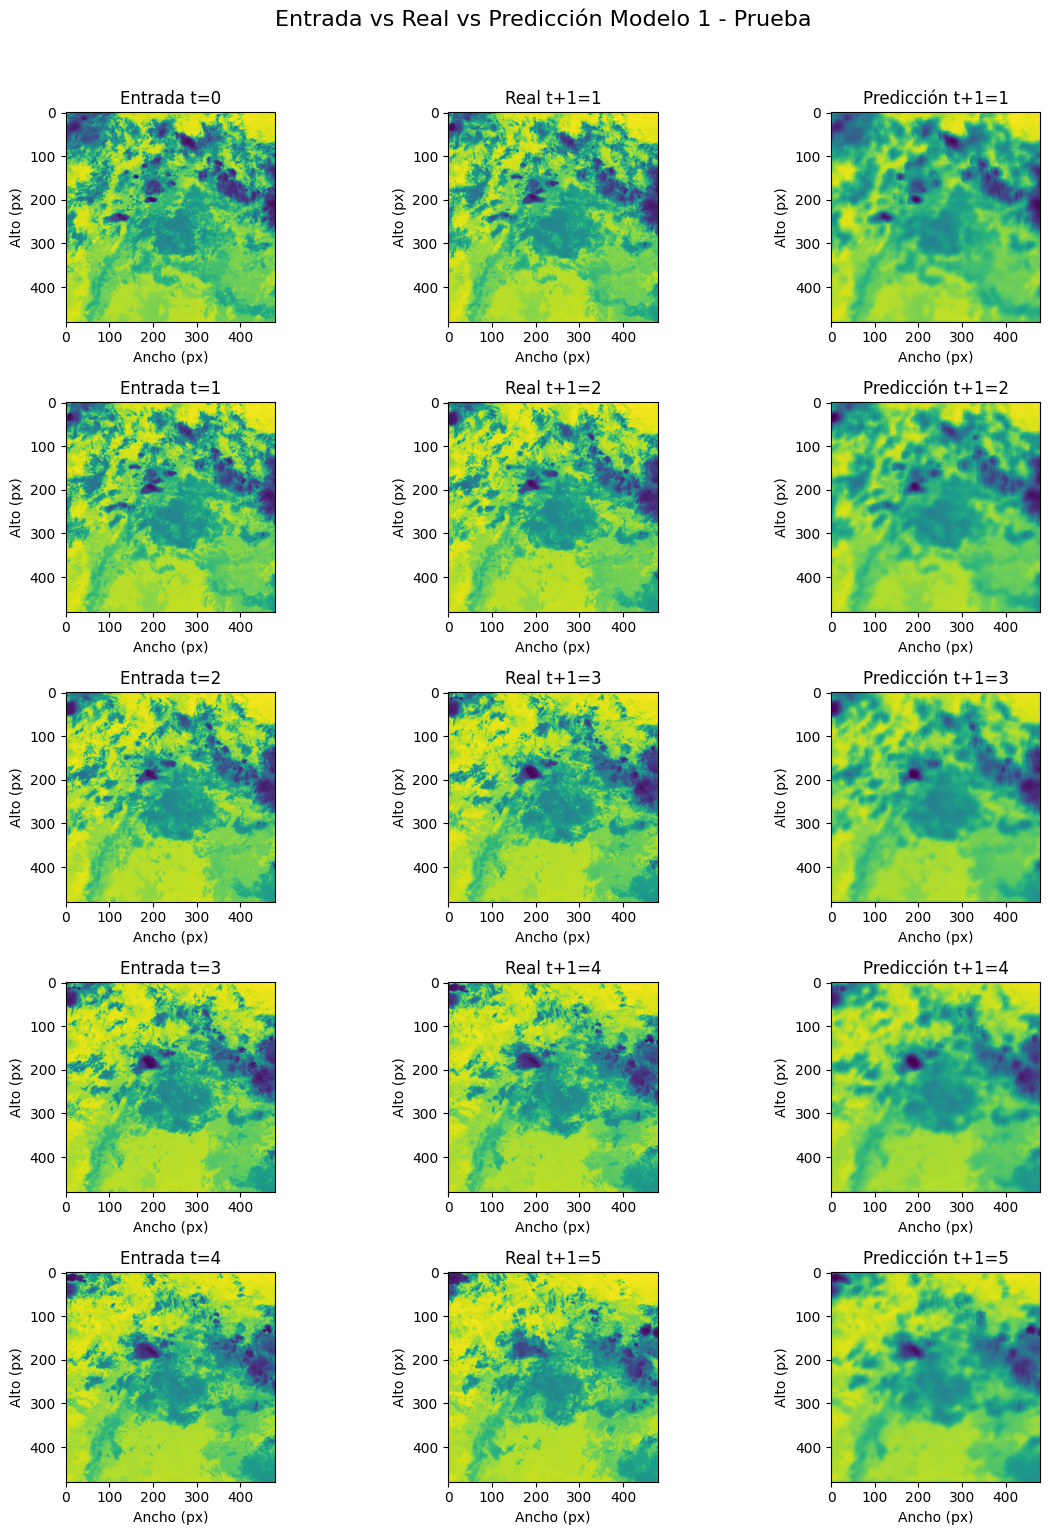

In [9]:
from tensorflow.keras.models import load_model
# Cargar el mejor modelo guardado
modelo_cargado = load_model("modelo1_best.h5", compile=False)

y_pred_test = modelo_cargado.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Metricas de prueba

In [11]:
# Obtener las métricas del modelo en el conjunto de prueba
modelo_cargado.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

loss, rmse, mape = modelo_cargado.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - loss: 0.0087 - mean_absolute_percentage_error: 22.3196 - root_mean_squared_error: 0.0935
Pérdida (MSE): 0.0087
RMSE: 0.0935
MAPE: 22.3196


Visualización de imagenes con conjunto de prueba

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step


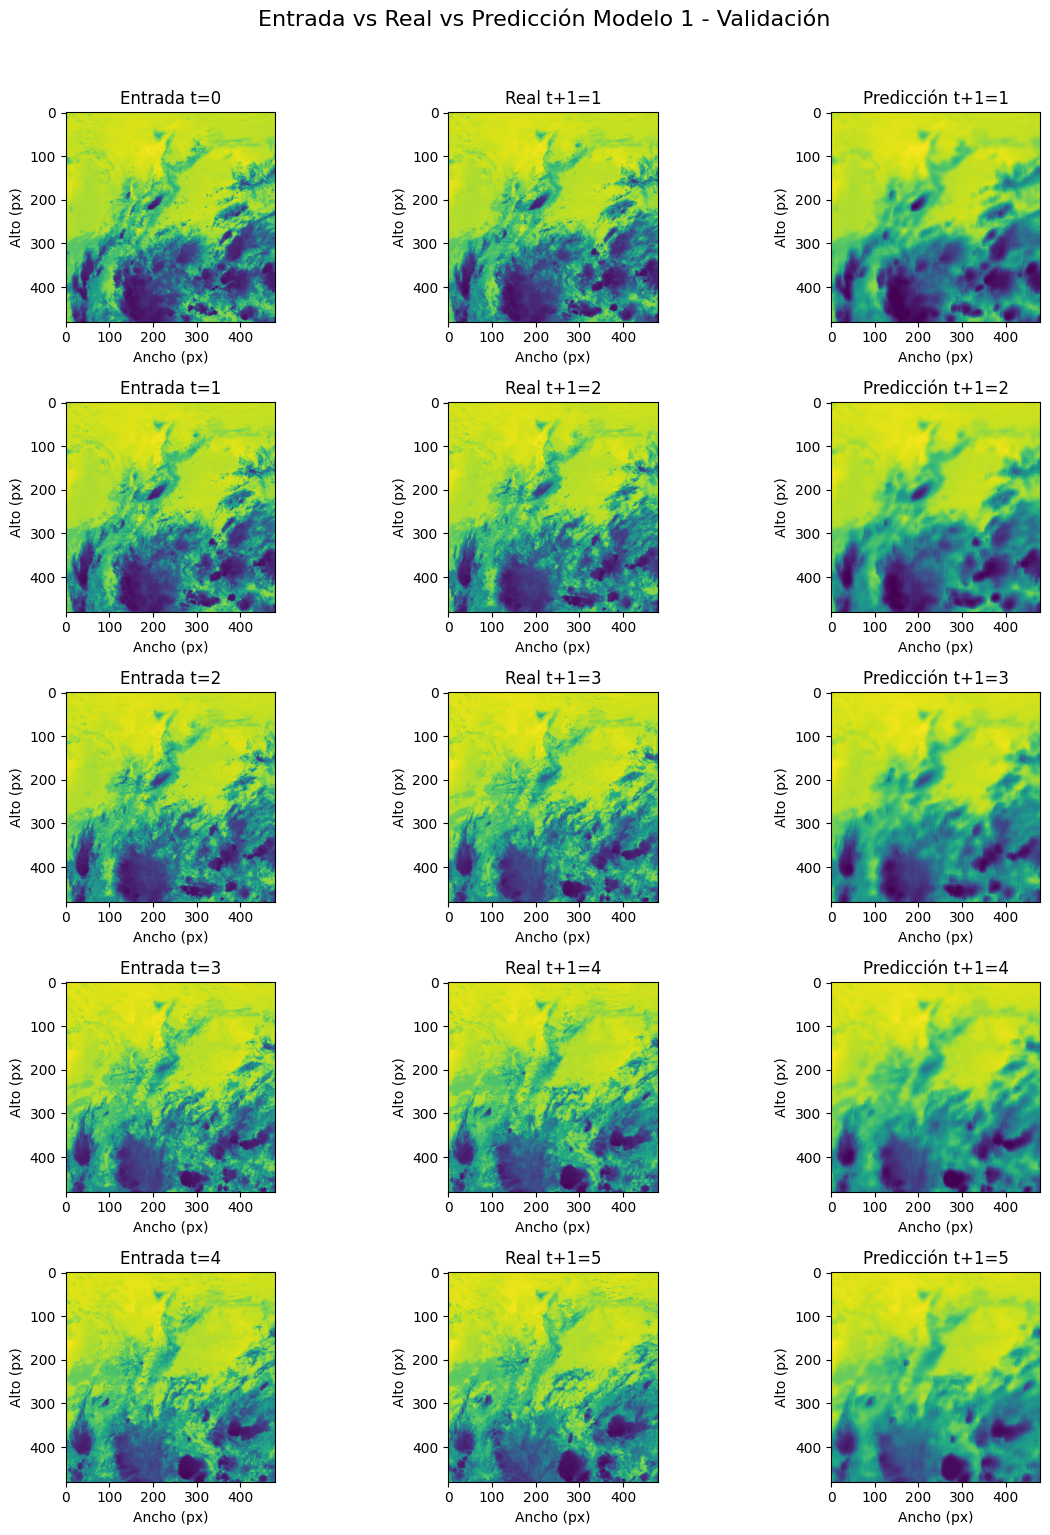

In [15]:
y_pred1_test = model1.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred1_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

In [1]:
from tensorflow.keras.models import load_model
# Cargar el mejor modelo guardado
modelo_cargado = load_model("modelo1_best.h5", compile=False)

2025-11-17 08:44:47.852264: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 08:44:47.869115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-17 08:44:47.889536: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-17 08:44:47.895266: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-17 08:44:47.911268: I tensorflow/core/platform/cpu_feature_guar

In [7]:
y_pred1 = modelo_cargado.predict(X)  # Genera las predicciones
mostrar_resultados2(
    X_train, y_train, y_pred1, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

2025-11-17 08:50:36.576865: W external/local_tsl/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.10GiB (rounded to 3333427200)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-11-17 08:50:36.576933: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2025-11-17 08:50:36.576948: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 19, Chunks in use: 19. 4.8KiB allocated for chunks. 4.8KiB in use in bin. 768B client-requested in use in bin.
2025-11-17 08:50:36.576957: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 1, Chunks in use: 1. 768B allocated for chunks. 768B in use in bin. 576B client-requested in use in bin.
2025-11-17 08:50:36.576964: I ext

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [2]:
y_pred_test = modelo_cargado.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

NameError: name 'X_test' is not defined